# Fair Comparison: Centralised vs Federated Learning on APHRODITE Data

Experiments for **precipitation** and **temperature**, each running three experiments
that isolate specific dimensions of the CL-vs-FL trade-off.

All experiments use **disjoint** client masks whose union equals the centralised mask,
and every model is evaluated with both the centralised mask and per-client masks.

| Experiment | CL training | FL training | Key question |
|---|---|---|---|
| **1** | All stations (centralised mask) | Random disjoint station split | Pure cost of federation (IID) |
| **2** | All stations (centralised mask) | Country-based disjoint split | Cost of non-IID geographic partition |
| **3** | Per-country CL (one model each) | Reuse FL from Exp 2 | Does FL leverage cross-country data? |

**Variables**: Precipitation (`precip`, V1901) and mean temperature (`tave`, V1808)
**Grid**: APHRODITE 0.25°, lon 60–105°E, lat 20–40°N
**Split**: Train 1998–2007, Test 2008–2011
**Model**: U-Net CNN with sparse pixel loss (MSE over labelled pixels only)

**Notebook layout**: Cells 1–13 define shared imports, config, and reusable functions. Parts A (precip) and B (temperature) can be run independently — just run cells 1–13 first, then skip to the desired variable section.

## Federated Learning: How It Works

### The Problem
In many real-world settings, observational data is **owned or managed by separate institutions** (e.g. national meteorological agencies in different countries). Privacy constraints, data sovereignty, or bandwidth limitations may prevent pooling all data onto a single server. **Federated Learning (FL)** allows these parties to collaboratively train a shared model **without exchanging raw data**.

### FedAvg (Federated Averaging)
This notebook uses **FedAvg** ([McMahan et al., 2017](https://arxiv.org/abs/1602.05629)), implemented via the [Flower](https://flower.ai/) simulation framework. The training loop proceeds as follows:

1. **Initialisation** — A central server initialises a global U-Net CNN model and broadcasts its parameters to all clients.
2. **Local training** — Each client (here: a country or a random station subset) independently trains a local copy of the model on its **own station data** for a fixed number of local epochs using Adam. No raw data leaves the client.
3. **Parameter upload** — After local training, each client sends its **updated model weights** (not gradients, not data) back to the server.
4. **Aggregation** — The server computes a **weighted average** of all client model weights, where the weight is proportional to each client's number of training examples:

$$\theta^{t+1} = \sum_{k=1}^{K} \frac{n_k}{n} \theta_k^{t+1}$$

where $K$ is the number of clients, $n_k$ is the number of training examples on client $k$, $n = \sum n_k$, and $\theta_k^{t+1}$ are client $k$'s locally updated parameters.

5. **Broadcast** — The new global model is sent back to all clients, and the process repeats from step 2.

Steps 2–5 constitute one **communication round**. After a fixed number of rounds the final global model is evaluated on the held-out test set.

### What Makes This Decentralised
- **Data stays local**: Each client only ever sees its own station observations. The server never accesses raw precipitation data.
- **Only model parameters travel**: Communication consists of serialised NumPy arrays of neural-network weights — the same shape regardless of dataset size.
- **No single point of data access**: Even if the server is compromised, it only holds averaged model weights, not individual client data.

### Configuration in This Notebook
| Setting | Value |
|---|---|
| FL framework | Flower `start_simulation()` |
| Aggregation strategy | `FedAvg` — all clients participate every round (`fraction_fit=1.0`) |
| Number of clients | 9 (one per country) or 5 (random subsets) |
| Communication rounds | 5 |
| Local epochs per round | 1 |
| Optimiser | Adam (lr = 0.001) |
| Server-side evaluation | After each round on the full centralised test set |
| Client-side evaluation | Disabled (`fraction_evaluate=0.0`) |

## 1. Setup and Imports

In [39]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import torch

sys.path.insert(0, os.path.join(os.getcwd(), 'examples'))
sys.path.insert(0, os.getcwd())

# autoreload
%load_ext autoreload
%autoreload 2

from fl4hma.utils.fed_utils import (
    load_aphro_data,
    run_centralised,
    run_federated,
    evaluate_model_with_mask,
    generate_random_split_masks,
    generate_country_boundary_masks,
)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU (' + torch.cuda.get_device_name() + ')' if torch.cuda.is_available() else 'CPU'}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.8.0+cu128
Device: GPU (NVIDIA A2)


## 2. Shared Configuration

In [40]:
# Model / training hyperparameters (shared across all variables)
BATCH_SIZE   = 16
NUM_EPOCHS   = 5     # centralised epochs
NUM_ROUNDS   = 5     # FL rounds
LOCAL_EPOCHS = 1     # FL local epochs per round
LR           = 0.001
IN_CHANNELS  = 3     # variable + lat + lon
BASE_FILTERS = 32
PATCH_SIZE   = 32
STRIDE       = 32
N_CLIENTS    = 5     # number of random-split FL clients

# Pre-existing station masks
STAT_MASK_DIR = "/data/hpcdata/users/kenzi22/FL4HMA/station_data/masks/stat"

# Countries with sufficient APHRODITE coverage (lon 60-105°E, lat 20-40°N).
# The following countries were excluded due to poor/no domain coverage
# (uncomment to re-enable):
#   "kazakhstan"  — southernmost point ~40.6°N, essentially above the 40°N cutoff
#   "kyrgyzstan"  — spans 39-43°N; only a thin southern strip falls within the domain
COUNTRIES = [
    "afghanistan", "china", "india",
    "nepal", "pakistan", "tajikistan", "uzbekistan",
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


## 3. Reusable Experiment Functions

The functions below encapsulate mask loading, training, evaluation, visualisation, and summary for **any** APHRODITE variable. Country masks and the centralised mask are loaded from pre-existing files; only the output mask and random splits are generated.

Define these cells once; run them once. The actual training cells are further below.



In [41]:
def load_masks(train_path, variable, local_mask_dir, n_clients):
    """Load pre-existing station masks, generate random split masks, and country boundary masks.

    Country station masks and the centralised mask are loaded from STAT_MASK_DIR.
    An output (land/sea) mask is derived from the data file and saved locally.
    Random split masks are generated from the centralised mask.
    Country boundary masks are rasterised from Natural Earth polygons.

    Returns (centralised_mask_path, out_mask_path, country_masks, random_masks,
             n_stations, centralised_mask_arr, boundary_masks).
    """
    os.makedirs(local_mask_dir, exist_ok=True)

    # --- Centralised mask (pre-existing) ---
    cent_mask_path = os.path.join(STAT_MASK_DIR, "centralised_mask.npy")
    centralised_mask_arr = np.load(cent_mask_path)
    n_stations = int(centralised_mask_arr.sum())
    print(f"  Loaded centralised_mask: density={centralised_mask_arr.mean()*100:.2f}%, "
          f"stations={n_stations}")

    # --- Output (land/sea) mask — derived from data ---
    out_mask_path = os.path.join(local_mask_dir, "out_mask.npy")
    if not os.path.exists(out_mask_path):
        ds_mask = xr.open_dataset(train_path).sel(lon=slice(60, 105), lat=slice(20, 40))
        out_mask_arr = np.where(np.isnan(ds_mask[variable][0].values), 0, 1)
        np.save(out_mask_path, out_mask_arr)
        ds_mask.close()
        print(f"  Generated out_mask: shape={out_mask_arr.shape}, "
              f"density={out_mask_arr.mean()*100:.1f}%")
    else:
        out_mask_arr = np.load(out_mask_path)
        print(f"  Loaded out_mask: density={out_mask_arr.mean()*100:.1f}%")

    # --- Country station masks (pre-existing) ---
    country_masks = {}
    for name in COUNTRIES:
        path = os.path.join(STAT_MASK_DIR, f"{name}_mask.npy")
        country_masks[name] = path
        m = np.load(path)
        print(f"    {name:15s}: {int(m.sum()):4d} stations")

    # --- Random split masks (generated from centralised mask) ---
    random_dir = os.path.join(local_mask_dir, "random_split")
    random_masks = generate_random_split_masks(
        centralised_mask_arr, n_clients,
        out_dir=random_dir, seed=42, prefix="random",
    )
    print(f"  Random split masks ({n_clients} clients):")
    for name, path in random_masks.items():
        m = np.load(path)
        print(f"    {name:15s}: {int(m.sum()):4d} stations")

    # --- Country boundary masks (rasterised from Natural Earth polygons) ---
    ds_coords = xr.open_dataset(train_path).sel(lon=slice(60, 105), lat=slice(20, 40))
    lat_vals = ds_coords.lat.values
    lon_vals = ds_coords.lon.values
    ds_coords.close()

    boundary_dir = os.path.join(local_mask_dir, "boundary")
    print(f"  Country boundary masks:")
    boundary_masks = generate_country_boundary_masks(
        lat_vals=lat_vals,
        lon_vals=lon_vals,
        countries=COUNTRIES,
        out_dir=boundary_dir,
        land_mask=out_mask_arr,
    )

    return (cent_mask_path, out_mask_path, country_masks, random_masks,
            n_stations, centralised_mask_arr, boundary_masks)

print("load_masks() defined")

load_masks() defined


### Mask visualisation function

In [42]:
def plot_masks(centralised_mask_arr, country_masks, random_masks, n_stations, title_prefix=""):
    """Visualise centralised, country-disjoint, and random-split masks."""
    n_cols = max(len(country_masks), len(random_masks)) + 1
    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 7))

    axes[0, 0].imshow(centralised_mask_arr, origin='lower', cmap='Blues')
    axes[0, 0].set_title(f'Centralised\n({n_stations} stations)', fontsize=9)
    axes[0, 0].axis('off')
    for i, (name, path) in enumerate(country_masks.items()):
        m = np.load(path)
        axes[0, i + 1].imshow(m, origin='lower', cmap='Oranges')
        axes[0, i + 1].set_title(f'{name.title()}\n({m.sum()} st)', fontsize=9)
        axes[0, i + 1].axis('off')
    for j in range(len(country_masks) + 1, n_cols):
        axes[0, j].axis('off')

    axes[1, 0].imshow(centralised_mask_arr, origin='lower', cmap='Blues')
    axes[1, 0].set_title(f'Centralised\n({n_stations} stations)', fontsize=9)
    axes[1, 0].axis('off')
    for i, (name, path) in enumerate(random_masks.items()):
        m = np.load(path)
        axes[1, i + 1].imshow(m, origin='lower', cmap='Greens')
        axes[1, i + 1].set_title(f'{name}\n({m.sum()} st)', fontsize=9)
        axes[1, i + 1].axis('off')
    for j in range(len(random_masks) + 1, n_cols):
        axes[1, j].axis('off')

    axes[0, 0].set_ylabel('Country split', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Random split', fontsize=12, fontweight='bold')
    plt.suptitle(f'{title_prefix}Disjoint Station Masks (union = centralised mask)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("plot_masks() defined")

plot_masks() defined


In [43]:
def run_all_experiments(da_train, da_test, centralised_mask_path, output_mask_path,
                        country_masks, random_masks, boundary_masks):
    """Run CL baseline + FL random + FL country + per-country CL models.
    
    Evaluates each model with:
      - station masks (sparse evaluation, as before)
      - country boundary masks (full-country extent evaluation)
    
    Returns a dict with all models and evaluation results needed for plotting.
    """
    results = {}

    # --- Centralised baseline ---
    print("\n" + "=" * 70)
    print("CENTRALISED BASELINE")
    print("=" * 70)
    cl_res = run_centralised(
        da_train=da_train, da_test=da_test,
        input_mask_path=centralised_mask_path,
        output_mask_path=output_mask_path,
        num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, lr=LR,
        in_channels=IN_CHANNELS, base_filters=BASE_FILTERS,
        patch_size=PATCH_SIZE, stride=STRIDE,
    )
    cl_model = cl_res['model']
    results['cl_model'] = cl_model

    # CL eval with centralised mask (station-based)
    cl_cent_eval = evaluate_model_with_mask(
        cl_model, da_test, centralised_mask_path, output_mask_path,
        batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
    results['cl_cent_eval'] = cl_cent_eval

    # --- Exp 1: FL with random split ---
    print("\n" + "=" * 70)
    print("EXPERIMENT 1: FL WITH RANDOM SPLIT")
    print("=" * 70)
    fl_random_res = run_federated(
        da_train=da_train, da_test=da_test,
        country_masks=random_masks,
        output_mask_path=output_mask_path,
        centralised_mask_path=centralised_mask_path,
        test_input_mask_path=centralised_mask_path,
        num_rounds=NUM_ROUNDS, local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE, lr=LR,
        in_channels=IN_CHANNELS, base_filters=BASE_FILTERS,
        patch_size=PATCH_SIZE, stride=STRIDE,
    )
    fl_random_model = fl_random_res['model']
    results['fl_random_model'] = fl_random_model

    # FL random eval with centralised mask (station-based)
    fl_cent_eval = evaluate_model_with_mask(
        fl_random_model, da_test, centralised_mask_path, output_mask_path,
        batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
    results['fl_cent_eval'] = fl_cent_eval

    # Per-client eval (Exp 1) — station masks
    exp1_per_client = {}
    for name, path in random_masks.items():
        cl_m = evaluate_model_with_mask(
            cl_model, da_test, path, output_mask_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        fl_m = evaluate_model_with_mask(
            fl_random_model, da_test, path, output_mask_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        exp1_per_client[name] = {'cl': cl_m, 'fl': fl_m}
    results['exp1_per_client'] = exp1_per_client

    # --- Exp 2: FL with country split ---
    print("\n" + "=" * 70)
    print("EXPERIMENT 2: FL WITH COUNTRY SPLIT")
    print("=" * 70)
    fl_country_res = run_federated(
        da_train=da_train, da_test=da_test,
        country_masks=country_masks,
        output_mask_path=output_mask_path,
        centralised_mask_path=centralised_mask_path,
        test_input_mask_path=centralised_mask_path,
        num_rounds=NUM_ROUNDS, local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE, lr=LR,
        in_channels=IN_CHANNELS, base_filters=BASE_FILTERS,
        patch_size=PATCH_SIZE, stride=STRIDE,
    )
    fl_country_model = fl_country_res['model']
    results['fl_country_model'] = fl_country_model

    # FL country eval with centralised mask (station-based)
    fl_country_cent_eval = evaluate_model_with_mask(
        fl_country_model, da_test, centralised_mask_path, output_mask_path,
        batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
    results['fl_country_cent_eval'] = fl_country_cent_eval

    # Per-country eval (Exp 2) — station masks
    exp2_per_country = {}
    for name, path in country_masks.items():
        cl_m = evaluate_model_with_mask(
            cl_model, da_test, path, output_mask_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        fl_m = evaluate_model_with_mask(
            fl_country_model, da_test, path, output_mask_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        exp2_per_country[name] = {'cl': cl_m, 'fl': fl_m}
    results['exp2_per_country'] = exp2_per_country

    # Per-country eval (Exp 2) — full boundary masks
    exp2_per_country_boundary = {}
    for name, bnd_path in boundary_masks.items():
        cl_m = evaluate_model_with_mask(
            cl_model, da_test, centralised_mask_path, bnd_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        fl_m = evaluate_model_with_mask(
            fl_country_model, da_test, centralised_mask_path, bnd_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        exp2_per_country_boundary[name] = {'cl': cl_m, 'fl': fl_m}
    results['exp2_per_country_boundary'] = exp2_per_country_boundary

    # --- Exp 3: Per-country CL models ---
    print("\n" + "=" * 70)
    print("EXPERIMENT 3: PER-COUNTRY CL MODELS")
    print("=" * 70)
    cl_country_models = {}
    for name, mask_path in country_masks.items():
        print(f"\n--- Training CL model for: {name.upper()} ---")
        res = run_centralised(
            da_train=da_train, da_test=da_test,
            input_mask_path=mask_path,
            output_mask_path=output_mask_path,
            num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, lr=LR,
            in_channels=IN_CHANNELS, base_filters=BASE_FILTERS,
            patch_size=PATCH_SIZE, stride=STRIDE,
        )
        cl_country_models[name] = res['model']
    results['cl_country_models'] = cl_country_models

    # 3A: Within-country — station masks
    exp3a = {}
    for name, mask_path in country_masks.items():
        cl_m = evaluate_model_with_mask(
            cl_country_models[name], da_test, mask_path, output_mask_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        fl_m = evaluate_model_with_mask(
            fl_country_model, da_test, mask_path, output_mask_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        exp3a[name] = {'cl': cl_m, 'fl': fl_m}
    results['exp3a'] = exp3a

    # 3A-boundary: Within-country — full boundary masks
    exp3a_boundary = {}
    for name, bnd_path in boundary_masks.items():
        cl_m = evaluate_model_with_mask(
            cl_country_models[name], da_test, country_masks[name], bnd_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        fl_m = evaluate_model_with_mask(
            fl_country_model, da_test, centralised_mask_path, bnd_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        exp3a_boundary[name] = {'cl': cl_m, 'fl': fl_m}
    results['exp3a_boundary'] = exp3a_boundary

    # 3B: Cross-country heatmap — station masks
    countries = list(country_masks.keys())
    nc = len(countries)
    heatmap = np.zeros((nc + 1, nc))
    for i, tc in enumerate(countries):
        for j, ec in enumerate(countries):
            met = evaluate_model_with_mask(
                cl_country_models[tc], da_test,
                country_masks[ec], output_mask_path,
                batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
            heatmap[i, j] = met['rmse']
    for j, ec in enumerate(countries):
        met = evaluate_model_with_mask(
            fl_country_model, da_test,
            country_masks[ec], output_mask_path,
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        heatmap[nc, j] = met['rmse']
    results['heatmap'] = heatmap

    # 3B-boundary: Cross-country heatmap — full boundary masks
    heatmap_bnd = np.zeros((nc + 1, nc))
    for i, tc in enumerate(countries):
        for j, ec in enumerate(countries):
            met = evaluate_model_with_mask(
                cl_country_models[tc], da_test,
                country_masks[tc], boundary_masks[ec],
                batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
            heatmap_bnd[i, j] = met['rmse']
    for j, ec in enumerate(countries):
        met = evaluate_model_with_mask(
            fl_country_model, da_test,
            centralised_mask_path, boundary_masks[ec],
            batch_size=BATCH_SIZE, patch_size=PATCH_SIZE, stride=STRIDE)
        heatmap_bnd[nc, j] = met['rmse']
    results['heatmap_boundary'] = heatmap_bnd
    results['countries'] = countries

    print("\n" + "=" * 70)
    print("ALL EXPERIMENTS COMPLETE")
    print("=" * 70)
    return results

print("run_all_experiments() defined")

run_all_experiments() defined


### Visualisation & summary functions

In [44]:
def plot_exp1(results, title_prefix=""):
    """Bar charts for Experiment 1 (random IID split)."""
    cl_cent = results['cl_cent_eval']
    fl_cent = results['fl_cent_eval']
    exp1 = results['exp1_per_client']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    approaches = ['Centralised', 'FL (Random)']
    rmse_vals = [cl_cent['rmse'], fl_cent['rmse']]
    colors = ['steelblue', 'coral']
    bars = ax1.bar(approaches, rmse_vals, color=colors, edgecolor='black', alpha=0.8)
    ax1.set_ylabel('RMSE')
    ax1.set_title('Eval: Centralised Mask (all stations)', fontweight='bold')
    for bar, val in zip(bars, rmse_vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

    clients = list(exp1.keys())
    cl_rmse = [exp1[c]['cl']['rmse'] for c in clients]
    fl_rmse = [exp1[c]['fl']['rmse'] for c in clients]
    x = np.arange(len(clients))
    w = 0.35
    ax2.bar(x - w/2, cl_rmse, w, label='Centralised', color='steelblue', edgecolor='black', alpha=0.8)
    ax2.bar(x + w/2, fl_rmse, w, label='FL (Random)', color='coral', edgecolor='black', alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(clients, rotation=45, ha='right')
    ax2.set_ylabel('RMSE')
    ax2.set_title('Eval: Per-Client Masks', fontweight='bold')
    ax2.legend()

    plt.suptitle(f'{title_prefix}Experiment 1: CL vs FL with Random Splitting',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_exp2(results, title_prefix=""):
    """Bar charts for Experiment 2 (country non-IID split)."""
    cl_cent = results['cl_cent_eval']
    fl_cent = results['fl_cent_eval']
    fl_country_cent = results['fl_country_cent_eval']
    exp2 = results['exp2_per_country']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    approaches = ['Centralised', 'FL (Random)', 'FL (Country)']
    rmse_vals = [cl_cent['rmse'], fl_cent['rmse'], fl_country_cent['rmse']]
    colors = ['steelblue', 'coral', 'goldenrod']
    bars = ax1.bar(approaches, rmse_vals, color=colors, edgecolor='black', alpha=0.8)
    ax1.set_ylabel('RMSE')
    ax1.set_title('Eval: Centralised Mask', fontweight='bold')
    for bar, val in zip(bars, rmse_vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

    countries = list(exp2.keys())
    cl_rmse = [exp2[c]['cl']['rmse'] for c in countries]
    fl_rmse = [exp2[c]['fl']['rmse'] for c in countries]
    x = np.arange(len(countries))
    w = 0.35
    ax2.bar(x - w/2, cl_rmse, w, label='Centralised', color='steelblue', edgecolor='black', alpha=0.8)
    ax2.bar(x + w/2, fl_rmse, w, label='FL (Country)', color='goldenrod', edgecolor='black', alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(countries, rotation=45, ha='right')
    ax2.set_ylabel('RMSE')
    ax2.set_title('Eval: Per-Country Station Masks', fontweight='bold')
    ax2.legend()

    plt.suptitle(f'{title_prefix}Experiment 2: CL vs FL with Country-Based Splitting',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_exp2_boundary(results, title_prefix=""):
    """Bar charts for Experiment 2 — full-country boundary evaluation."""
    exp2_bnd = results['exp2_per_country_boundary']
    countries = list(exp2_bnd.keys())
    cl_rmse = [exp2_bnd[c]['cl']['rmse'] for c in countries]
    fl_rmse = [exp2_bnd[c]['fl']['rmse'] for c in countries]

    x = np.arange(len(countries))
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, cl_rmse, w, label='Centralised', color='steelblue', edgecolor='black', alpha=0.8)
    ax.bar(x + w/2, fl_rmse, w, label='FL (Country)', color='goldenrod', edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([c.title() for c in countries], rotation=45, ha='right')
    ax.set_ylabel('RMSE')
    ax.set_title(f'{title_prefix}Exp 2 (Boundary): CL vs FL — Full-Country Extent',
                 fontsize=14, fontweight='bold')
    ax.legend()
    for bars, vals, color in [(ax.containers[0], cl_rmse, 'steelblue'),
                               (ax.containers[1], fl_rmse, 'goldenrod')]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                    f'{val:.3f}', ha='center', fontsize=8, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()


def plot_exp3a(results, title_prefix=""):
    """Grouped bar chart for Experiment 3A (within-country)."""
    exp3a = results['exp3a']
    countries = list(exp3a.keys())
    cl_rmse = [exp3a[c]['cl']['rmse'] for c in countries]
    fl_rmse = [exp3a[c]['fl']['rmse'] for c in countries]

    x = np.arange(len(countries))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w/2, cl_rmse, w, label='CL (country-specific)', color='steelblue', edgecolor='black', alpha=0.8)
    ax.bar(x + w/2, fl_rmse, w, label='FL (all countries)', color='goldenrod', edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([c.title() for c in countries], rotation=45, ha='right')
    ax.set_ylabel('RMSE')
    ax.set_title(f'{title_prefix}Exp 3A: Within-Country (Stations) — CL(country) vs FL',
                 fontsize=14, fontweight='bold')
    ax.legend()
    for bars, vals, color in [(ax.containers[0], cl_rmse, 'steelblue'),
                               (ax.containers[1], fl_rmse, 'goldenrod')]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                    f'{val:.3f}', ha='center', fontsize=8, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()


def plot_exp3a_boundary(results, title_prefix=""):
    """Grouped bar chart for Experiment 3A — full-country boundary evaluation."""
    exp3a_bnd = results['exp3a_boundary']
    countries = list(exp3a_bnd.keys())
    cl_rmse = [exp3a_bnd[c]['cl']['rmse'] for c in countries]
    fl_rmse = [exp3a_bnd[c]['fl']['rmse'] for c in countries]

    x = np.arange(len(countries))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w/2, cl_rmse, w, label='CL (country-specific)', color='steelblue', edgecolor='black', alpha=0.8)
    ax.bar(x + w/2, fl_rmse, w, label='FL (all countries)', color='goldenrod', edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([c.title() for c in countries], rotation=45, ha='right')
    ax.set_ylabel('RMSE')
    ax.set_title(f'{title_prefix}Exp 3A (Boundary): Within-Country — Full Extent',
                 fontsize=14, fontweight='bold')
    ax.legend()
    for bars, vals, color in [(ax.containers[0], cl_rmse, 'steelblue'),
                               (ax.containers[1], fl_rmse, 'goldenrod')]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                    f'{val:.3f}', ha='center', fontsize=8, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()


def plot_exp3b(results, title_prefix="", use_boundary=False):
    """Heatmap for Experiment 3B (cross-country generalisation).
    
    If use_boundary=True, plots the boundary-based heatmap instead.
    """
    key = 'heatmap_boundary' if use_boundary else 'heatmap'
    heatmap = results[key]
    countries = results['countries']
    n = len(countries)
    row_labels = [f'CL({c})' for c in countries] + ['FL']
    suffix = ' (Full Boundary)' if use_boundary else ' (Stations)'

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(heatmap, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(n))
    ax.set_xticklabels([c.title() for c in countries], rotation=45, ha='right')
    ax.set_yticks(range(n + 1))
    ax.set_yticklabels(row_labels)
    ax.set_xlabel('Evaluation Country', fontsize=12)
    ax.set_ylabel('Training Approach', fontsize=12)
    ax.set_title(f'{title_prefix}Exp 3B{suffix}: Cross-Country RMSE',
                 fontsize=14, fontweight='bold')

    for i in range(n + 1):
        for j in range(n):
            text = f'{heatmap[i, j]:.3f}'
            color = 'white' if heatmap[i, j] > heatmap.mean() else 'black'
            weight = 'bold' if i == n else 'normal'
            ax.text(j, i, text, ha='center', va='center', fontsize=9,
                    color=color, fontweight=weight)

    ax.axhline(y=n - 0.5, color='white', linewidth=3)
    plt.colorbar(im, ax=ax, label='RMSE')
    plt.tight_layout()
    plt.show()

print("Plotting functions defined")

Plotting functions defined


---
# Part A — Precipitation Experiments

APHRODITE daily precipitation (`precip`), V1901, 0.25deg.

In [45]:
# --- Precipitation data paths ---
PRECIP_TRAIN = "/data/hpcdata/users/kenzi22/data/APHRODITE/daily/APHRO_MA_025deg_V1901.1998-2007.nc"
PRECIP_TEST  = "/data/hpcdata/users/kenzi22/data/APHRODITE/daily/APHRO_MA_025deg_V1901.2008-2011.nc"
PRECIP_MASK_DIR = "station_data/masks_precip"

# Load data
da_train_precip, da_test_precip = load_aphro_data(PRECIP_TRAIN, PRECIP_TEST, variable="precip")
print(f"Precip training shape: {da_train_precip.shape}")
print(f"Precip test shape:     {da_test_precip.shape}")

# Load masks
PRECIP_CENT_MASK, PRECIP_OUT_MASK, precip_country_masks, precip_random_masks, \
    precip_n_stations, precip_cent_mask, precip_boundary_masks = load_masks(
        PRECIP_TRAIN, "precip", PRECIP_MASK_DIR, N_CLIENTS)

Precip training shape: (3, 3652, 80, 180)
Precip test shape:     (3, 1461, 80, 180)
  Loaded centralised_mask: density=12.44%, stations=1792
  Loaded out_mask: density=93.9%
    afghanistan    :   24 stations
    china          :   76 stations
    india          : 1613 stations
    nepal          :   22 stations
    pakistan       :   53 stations
    tajikistan     :   73 stations
    uzbekistan     :   44 stations
  Random split masks (5 clients):
    client_0       :  359 stations
    client_1       :  359 stations
    client_2       :  358 stations
    client_3       :  358 stations
    client_4       :  358 stations
  Country boundary masks:
    afghanistan    : cached ( 1005 pixels)
    china          : cached ( 5647 pixels)
    india          : cached ( 3224 pixels)
    nepal          : cached (  213 pixels)
    pakistan       : cached ( 1307 pixels)
    tajikistan     : cached (  215 pixels)
    uzbekistan     : cached (  142 pixels)


### Precipitation mask overview

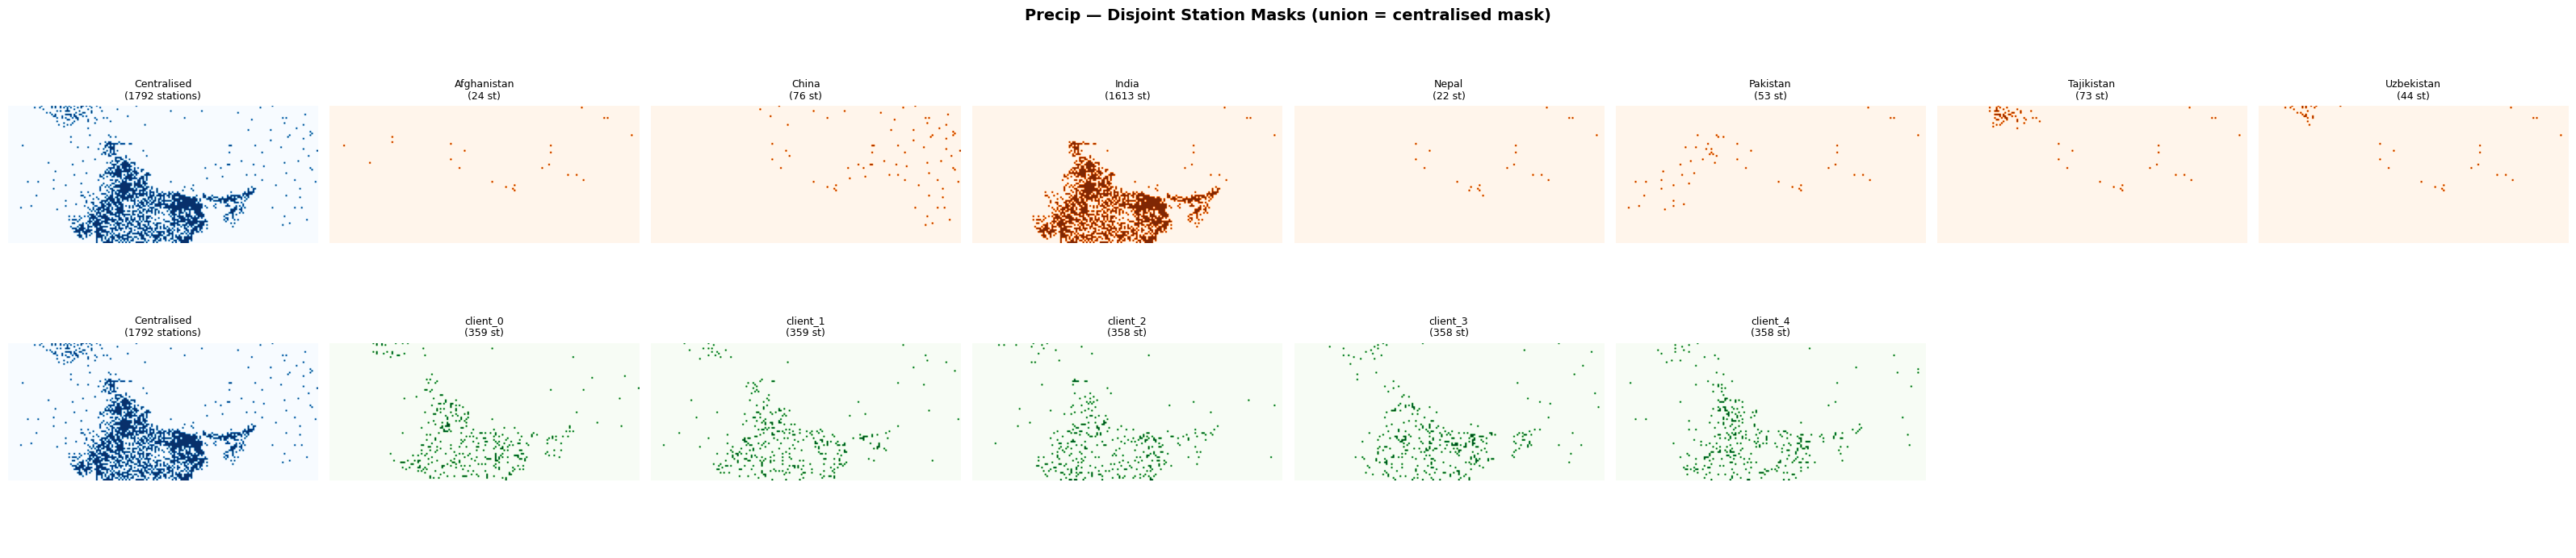

In [46]:
plot_masks(precip_cent_mask, precip_country_masks, precip_random_masks,
           precip_n_stations, title_prefix="Precip — ")

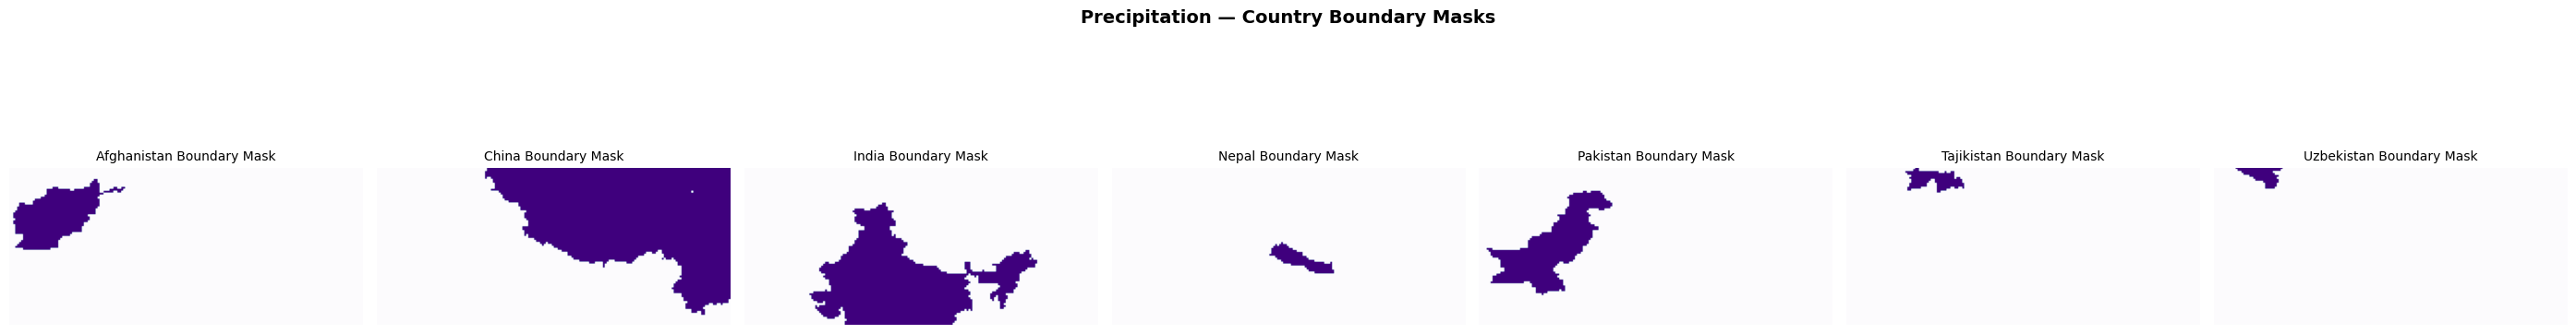

In [47]:
# plot precip_boundary_masks
fig, axes = plt.subplots(1, len(precip_boundary_masks), figsize=(4 * len(precip_boundary_masks), 5))
for ax, (name, path) in zip(axes, precip_boundary_masks.items()):
    bnd_mask = np.load(path)
    ax.imshow(bnd_mask, origin='lower', cmap='Purples')
    ax.set_title(f'{name.title()} Boundary Mask', fontsize=10)
    ax.axis('off')
plt.suptitle('Precipitation — Country Boundary Masks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
# Run all precipitation experiments
precip_results = run_all_experiments(
    da_train_precip, da_test_precip,
    PRECIP_CENT_MASK, PRECIP_OUT_MASK,
    precip_country_masks, precip_random_masks,
    precip_boundary_masks,
)


CENTRALISED BASELINE
Centralised Training
  Train samples : 36520
  Test samples  : 14610
  Epochs        : 5
  Device        : cuda

  Epoch 1/5: train_loss=0.9926, test_mse=14.762399, test_rmse=3.842187
  Epoch 2/5: train_loss=0.9635, test_mse=14.685608, test_rmse=3.832181
  Epoch 3/5: train_loss=0.9569, test_mse=14.666032, test_rmse=3.829626
  Epoch 4/5: train_loss=0.9571, test_mse=14.628156, test_rmse=3.824677
  Epoch 5/5: train_loss=0.9560, test_mse=14.599438, test_rmse=3.820921

Final centralised test MSE : 14.599438
Final centralised test RMSE: 3.820921

EXPERIMENT 1: FL WITH RANDOM SPLIT
Federated Learning – Sparse Pixel APHRODITE Precip (Flower)
  Clients       : 5 (client_0, client_1, client_2, client_3, client_4)
  Rounds        : 5
  Local epochs  : 1
  Device        : cuda

  Client 'client_0': 36520 patches
  Client 'client_1': 36520 patches
  Client 'client_2': 36520 patches
  Client 'client_3': 36520 patches
  Client 'client_4': 36520 patches



	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-04-15 15:30:50,470	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 48.0, 'object_store_memory': 153687724032.0, 'accelerator_type:A2': 1.0, 'memory': 348604689408.0, 'GPU': 1.0, 'node:10.27.3.178': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.2}
INFO :     

  [Server] Round 0: loss=1.4914, mse=23.491412, rmse=4.846794


(ClientAppActor pid=3273574) /users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
(ClientAppActor pid=3273574)   prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
(ClientAppActor pid=3273574) /users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
(ClientAppActor pid=3273574)   parse = parser.parseString(pattern)
(ClientAppActor pid=3273574) /users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
(ClientAppActor pid=3273574)   parser.resetCache()
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      fit progress: (1, 1.0768893380981566, {'mse': 16.782796792726742, 'rmse': np.float64(4.096681192468696)}, 230.8482645228505)
INF

  [Server] Round 1: loss=1.0769, mse=16.782797, rmse=4.096681


...

  [Server] Round 3: loss=1.0001, mse=15.630634, rmse=3.953560


INFO :      aggregate_fit: received 7 results and 0 failures
INFO :      fit progress: (4, 1.0010395112734785, {'mse': 15.647413808585469, 'rmse': np.float64(3.9556812066426015)}, 1193.1975528527983)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 5]
INFO :      configure_fit: strategy sampled 7 clients (out of 7)


  [Server] Round 4: loss=1.0010, mse=15.647414, rmse=3.955681


INFO :      aggregate_fit: received 7 results and 0 failures
INFO :      fit progress: (5, 0.9951812207079299, {'mse': 15.556018355249527, 'rmse': np.float64(3.944111858866268)}, 1489.3509129076265)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 1489.35s
INFO :      	History (loss, centralized):
INFO :      		round 0: 1.4913574775081755
INFO :      		round 1: 1.0661069685898934
INFO :      		round 2: 1.0207832656001887
INFO :      		round 3: 1.000118629693072
INFO :      		round 4: 1.0010395112734785
INFO :      		round 5: 0.9951812207079299
INFO :      	History (metrics, centralized):
INFO :      	{'mse': [(0, 23.491412075240515),
INFO :      	         (1, 16.625963759347716),
INFO :      	         (2, 15.941100723030662),
INFO :      	         (3, 15.630633818444183),
INFO :      	         (4, 15.647413808585469),
INFO :      	         (5, 15.556018355249527)],
INFO :      	 'rmse': [(

  [Server] Round 5: loss=0.9952, mse=15.556018, rmse=3.944112

Final federated test MSE  after 5 rounds: 15.556018
Final federated test RMSE after 5 rounds: 3.944112

EXPERIMENT 3: PER-COUNTRY CL MODELS

--- Training CL model for: AFGHANISTAN ---
Centralised Training
  Train samples : 36520
  Test samples  : 14610
  Epochs        : 5
  Device        : cuda

  Epoch 1/5: train_loss=1.2158, test_mse=18.308906, test_rmse=4.278891
  Epoch 2/5: train_loss=1.1784, test_mse=18.174125, test_rmse=4.263112
  Epoch 3/5: train_loss=1.1713, test_mse=18.099416, test_rmse=4.254341
  Epoch 4/5: train_loss=1.1687, test_mse=18.107967, test_rmse=4.255346
  Epoch 5/5: train_loss=1.1642, test_mse=18.080158, test_rmse=4.252077

Final centralised test MSE : 18.080158
Final centralised test RMSE: 4.252077

--- Training CL model for: CHINA ---
Centralised Training
  Train samples : 36520
  Test samples  : 14610
  Epochs        : 5
  Device        : cuda

  Epoch 1/5: train_loss=1.1902, test_mse=17.827373, test

### Precipitation results

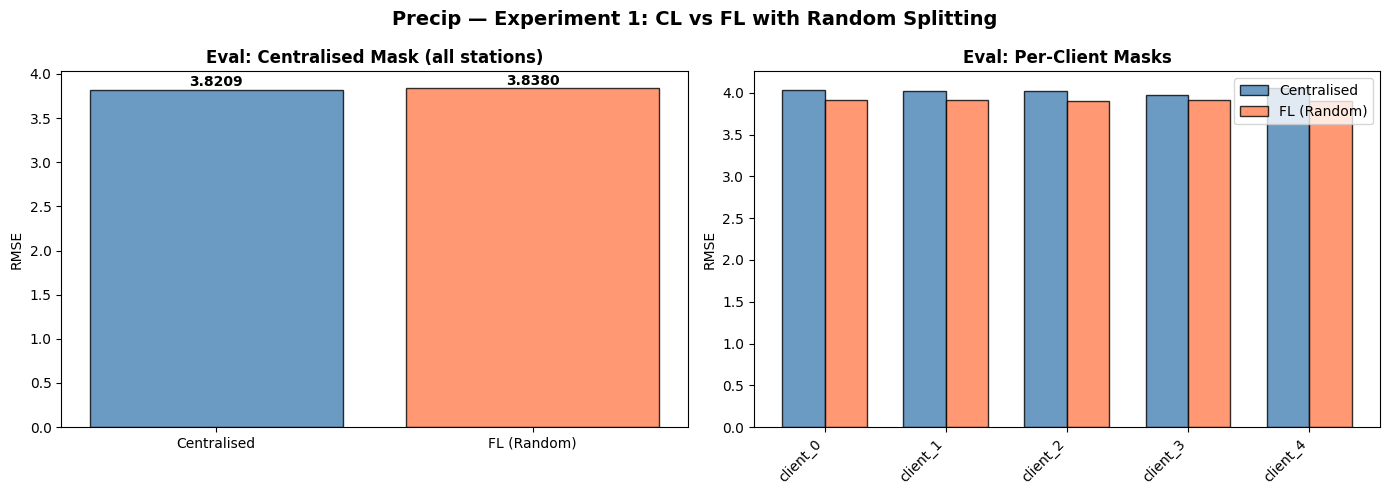

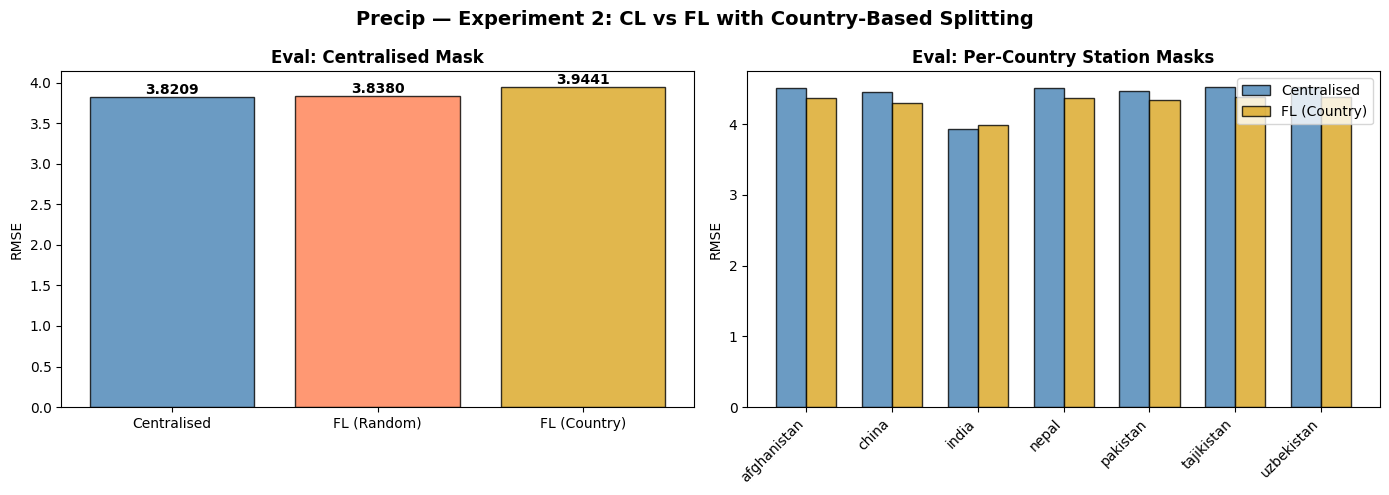

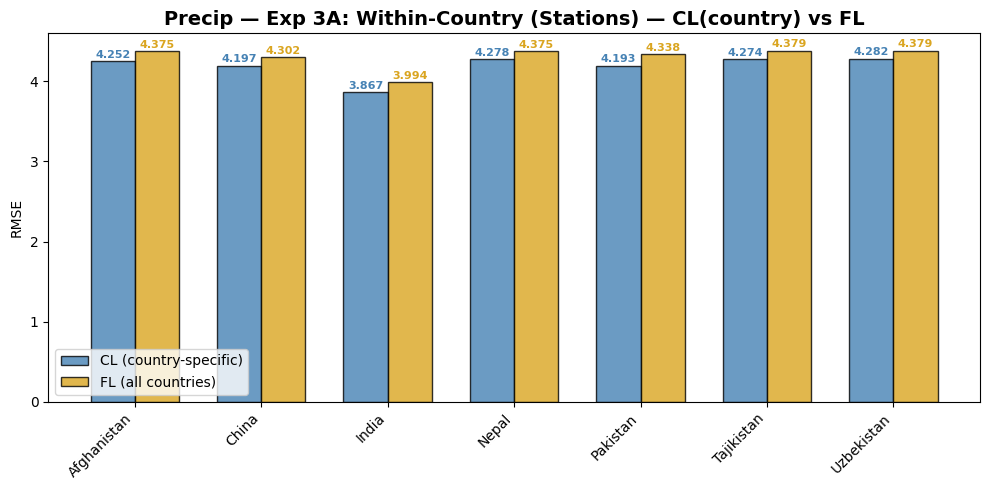

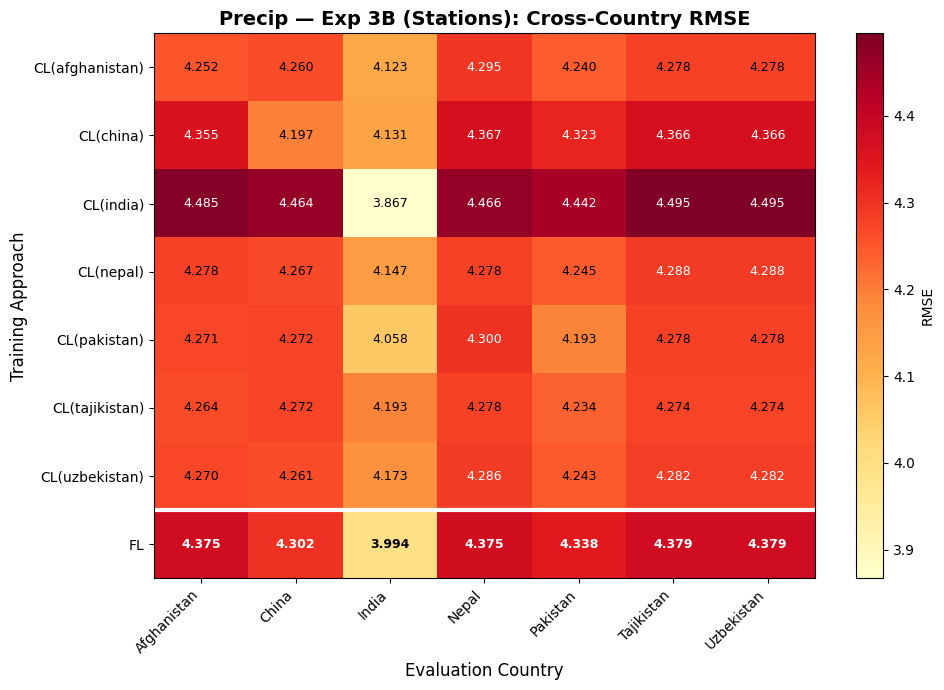

In [49]:
# Precipitation results — visualisation and summary
plot_exp1(precip_results, title_prefix="Precip — ")
plot_exp2(precip_results, title_prefix="Precip — ")
plot_exp3a(precip_results, title_prefix="Precip — ")
plot_exp3b(precip_results, title_prefix="Precip — ")

In [50]:
# =====================================================================
# Part B — Temperature Experiments
# APHRODITE daily mean temperature (tave), V1808, 0.25 deg.
# Same grid and train/test period split as precipitation.
# Runs Experiments 1, 2, 3A, 3B identically to Part A.
# =====================================================================

In [51]:
# --- Temperature data paths ---
TAVE_TRAIN = "/data/hpcdata/users/kenzi22/data/APHRODITE/daily/APHRO_MA_TAVE_025deg_V1808.1998-2007.nc"
TAVE_TEST  = "/data/hpcdata/users/kenzi22/data/APHRODITE/daily/APHRO_MA_TAVE_025deg_V1808.2008-2011.nc"
TAVE_MASK_DIR = "station_data/masks_tave"

# Load data
da_train_tave, da_test_tave = load_aphro_data(TAVE_TRAIN, TAVE_TEST, variable="tave")
print(f"Temperature training shape: {da_train_tave.shape}")
print(f"Temperature test shape:     {da_test_tave.shape}")

# Load masks
TAVE_CENT_MASK, TAVE_OUT_MASK, tave_country_masks, tave_random_masks, \
    tave_n_stations, tave_cent_mask, tave_boundary_masks = load_masks(
        TAVE_TRAIN, "tave", TAVE_MASK_DIR, N_CLIENTS)

Temperature training shape: (3, 3652, 80, 180)
Temperature test shape:     (3, 1461, 80, 180)
  Loaded centralised_mask: density=12.44%, stations=1792
  Loaded out_mask: density=93.9%
    afghanistan    :   24 stations
    china          :   76 stations
    india          : 1613 stations
    nepal          :   22 stations
    pakistan       :   53 stations
    tajikistan     :   73 stations
    uzbekistan     :   44 stations
  Random split masks (5 clients):
    client_0       :  359 stations
    client_1       :  359 stations
    client_2       :  358 stations
    client_3       :  358 stations
    client_4       :  358 stations
  Country boundary masks:
    afghanistan    :  1005 pixels
    china          :  5647 pixels
    india          :  3224 pixels
    nepal          :   213 pixels
    pakistan       :  1307 pixels
    tajikistan     :   215 pixels
    uzbekistan     :   142 pixels


### Temperature mask overview

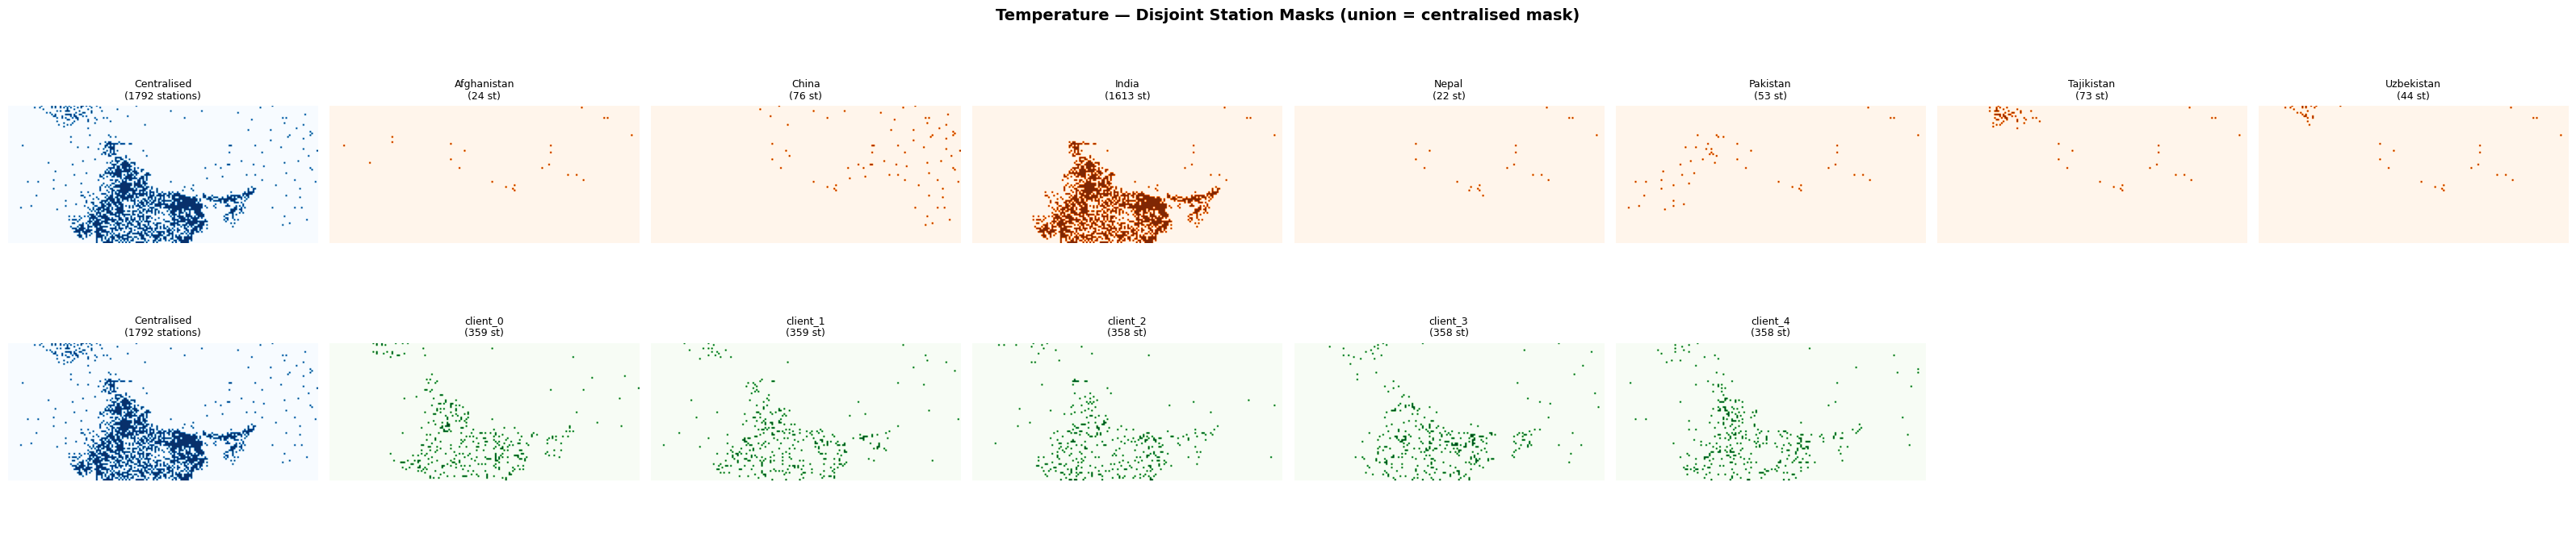

In [52]:
plot_masks(tave_cent_mask, tave_country_masks, tave_random_masks,
           tave_n_stations, title_prefix="Temperature — ")

In [53]:
# Run all temperature experiments
tave_results = run_all_experiments(
    da_train_tave, da_test_tave,
    TAVE_CENT_MASK, TAVE_OUT_MASK,
    tave_country_masks, tave_random_masks,
    tave_boundary_masks,
)


CENTRALISED BASELINE


Centralised Training
  Train samples : 36520
  Test samples  : 14610
  Epochs        : 5
  Device        : cuda

  Epoch 1/5: train_loss=0.4912, test_mse=6.849647, test_rmse=2.617183
  Epoch 2/5: train_loss=0.4714, test_mse=6.813953, test_rmse=2.610355
  Epoch 3/5: train_loss=0.4699, test_mse=6.811834, test_rmse=2.609949
  Epoch 4/5: train_loss=0.4700, test_mse=6.807894, test_rmse=2.609194
  Epoch 5/5: train_loss=0.4696, test_mse=6.803988, test_rmse=2.608445

Final centralised test MSE : 6.803988
Final centralised test RMSE: 2.608445

EXPERIMENT 1: FL WITH RANDOM SPLIT
Federated Learning – Sparse Pixel APHRODITE Precip (Flower)
  Clients       : 5 (client_0, client_1, client_2, client_3, client_4)
  Rounds        : 5
  Local epochs  : 1
  Device        : cuda

  Client 'client_0': 36520 patches
  Client 'client_1': 36520 patches
  Client 'client_2': 36520 patches
  Client 'client_3': 36520 patches
  Client 'client_4': 36520 patches



	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-04-15 22:07:33,369	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 48.0, 'memory': 348565689754.0, 'accelerator_type:A2': 1.0, 'object_store_memory': 153671009894.0, 'GPU': 1.0, 'node:10.27.3.178': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.2}
INFO :     

  [Server] Round 0: loss=1.0460, mse=15.860467, rmse=3.982520


(ClientAppActor pid=2994785) /users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
(ClientAppActor pid=2994785)   prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
(ClientAppActor pid=2994785) /users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
(ClientAppActor pid=2994785)   parse = parser.parseString(pattern)
(ClientAppActor pid=2994785) /users/marron31/.venv/lib64/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
(ClientAppActor pid=2994785)   parser.resetCache()
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      fit progress: (1, 0.5880033790217447, {'mse': 9.063046174394925, 'rmse': np.float64(3.0104893579607492)}, 229.85283364215866)
IN

...

  [Server] Round 3: loss=0.5714, mse=8.641123, rmse=2.939579


INFO :      aggregate_fit: received 7 results and 0 failures
INFO :      fit progress: (4, 0.5596233604871209, {'mse': 8.47262196584515, 'rmse': np.float64(2.910776866378656)}, 1195.1328180576675)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 5]
INFO :      configure_fit: strategy sampled 7 clients (out of 7)


  [Server] Round 4: loss=0.5596, mse=8.472622, rmse=2.910777


INFO :      aggregate_fit: received 7 results and 0 failures
INFO :      fit progress: (5, 0.5577053632546436, {'mse': 8.435221769418762, 'rmse': np.float64(2.904345325442338)}, 1491.5159998857416)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 1491.52s
INFO :      	History (loss, centralized):
INFO :      		round 0: 1.0460465697803956
INFO :      		round 1: 0.58386255689862
INFO :      		round 2: 0.5969644748978724
INFO :      		round 3: 0.571367077089243
INFO :      		round 4: 0.5596233604871209
INFO :      		round 5: 0.5577053632546436
INFO :      	History (metrics, centralized):
INFO :      	{'mse': [(0, 15.86046688624299),
INFO :      	         (1, 8.827393701224368),
INFO :      	         (2, 9.02641981579078),
INFO :      	         (3, 8.641122633348784),
INFO :      	         (4, 8.47262196584515),
INFO :      	         (5, 8.435221769418762)],
INFO :      	 'rmse': [(0, np.float

  [Server] Round 5: loss=0.5577, mse=8.435222, rmse=2.904345

Final federated test MSE  after 5 rounds: 8.435222
Final federated test RMSE after 5 rounds: 2.904345

EXPERIMENT 3: PER-COUNTRY CL MODELS

--- Training CL model for: AFGHANISTAN ---
Centralised Training
  Train samples : 36520
  Test samples  : 14610
  Epochs        : 5
  Device        : cuda

  Epoch 1/5: train_loss=0.5656, test_mse=7.695864, test_rmse=2.774142
  Epoch 2/5: train_loss=0.5111, test_mse=7.554219, test_rmse=2.748494
  Epoch 3/5: train_loss=0.5084, test_mse=7.557542, test_rmse=2.749098
  Epoch 4/5: train_loss=0.5070, test_mse=7.522768, test_rmse=2.742766
  Epoch 5/5: train_loss=0.5059, test_mse=7.523636, test_rmse=2.742925

Final centralised test MSE : 7.523636
Final centralised test RMSE: 2.742925

--- Training CL model for: CHINA ---
Centralised Training
  Train samples : 36520
  Test samples  : 14610
  Epochs        : 5
  Device        : cuda

  Epoch 1/5: train_loss=0.5776, test_mse=8.297760, test_rmse=2.8

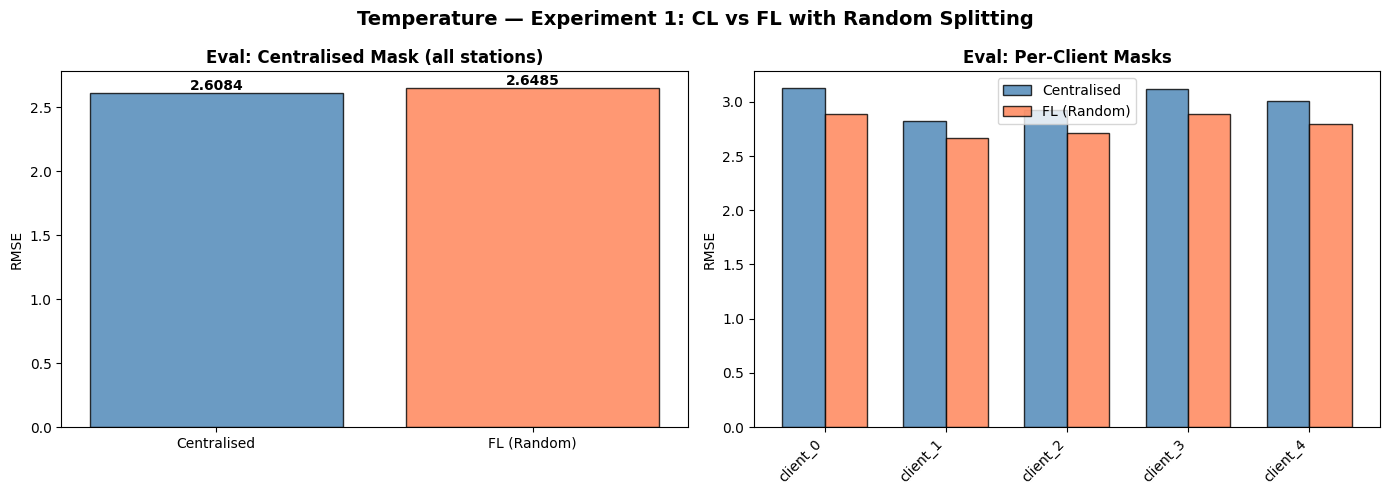

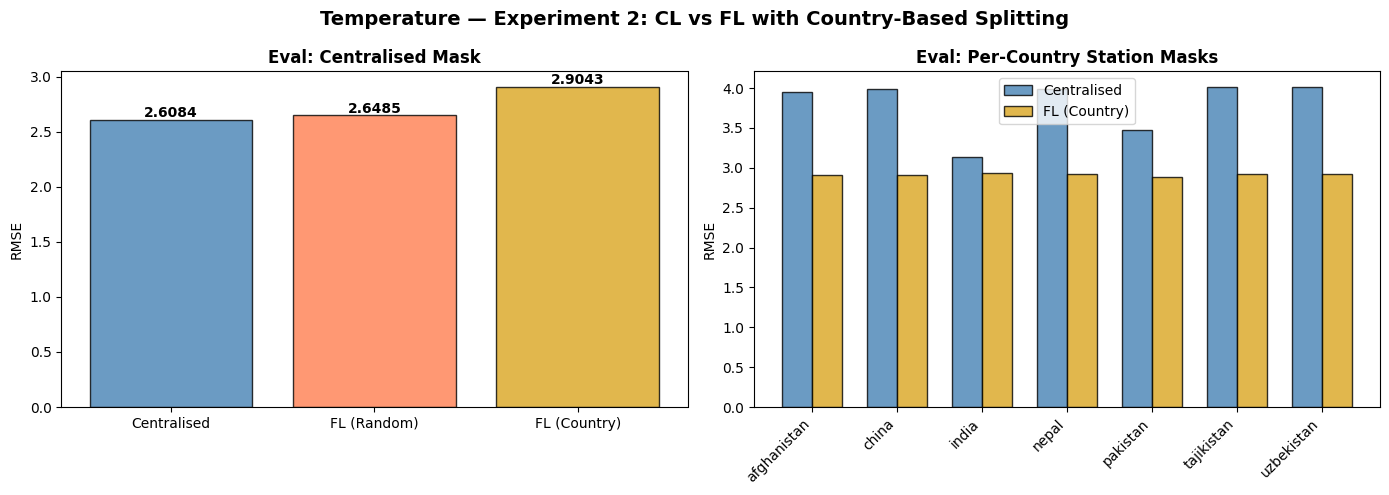

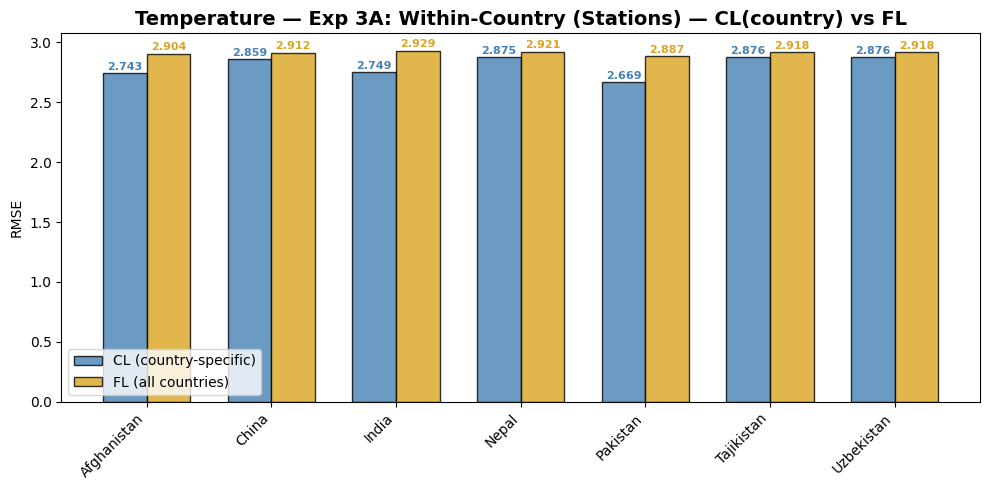

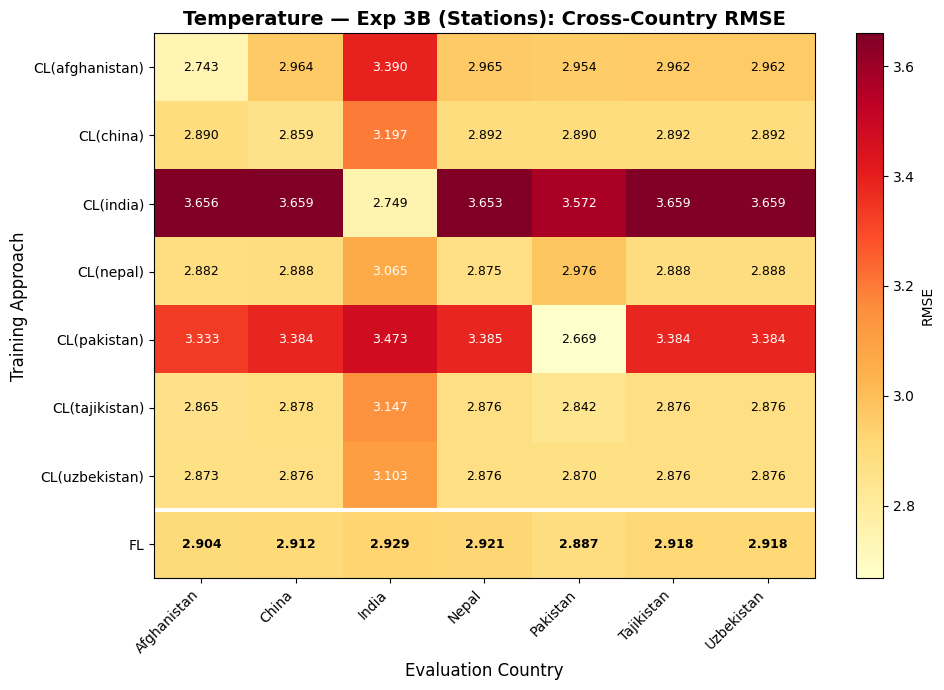

In [54]:
# Temperature results — visualisation and summary
plot_exp1(tave_results, title_prefix="Temperature — ")
plot_exp2(tave_results, title_prefix="Temperature — ")
plot_exp3a(tave_results, title_prefix="Temperature — ")
plot_exp3b(tave_results, title_prefix="Temperature — ")

---
# Combined Summary

In [55]:
if 'precip_results' in dir():
    print_summary(precip_results, variable_name="Precipitation")
    print()
else:
    print("(Precipitation results not in scope — run Part A cells to populate.)")
    print()

if 'tave_results' in dir():
    print_summary(tave_results, variable_name="Temperature")
else:
    print("(Temperature results not in scope — run Part B cells to populate.)")


EXPERIMENT SUMMARY — PRECIPITATION

--- Experiment 1: Random Split (IID) ---
  CL RMSE:          3.8209
  FL (Random) RMSE: 3.8380
  Gap:              +0.0171

--- Experiment 2: Country Split (non-IID) ---
  CL RMSE:           3.8209
  FL (Random) RMSE:  3.8380
  FL (Country) RMSE: 3.9441
  IID gap:           +0.0171
  Non-IID gap:       +0.1232
  Non-IID penalty:   +0.1061

--- Experiment 3A: Per-Country CL vs FL (within-country) ---
  afghanistan    : CL(i)=4.2521, FL=4.3754, diff=-0.1233
  china          : CL(i)=4.1969, FL=4.3017, diff=-0.1048
  india          : CL(i)=3.8673, FL=3.9937, diff=-0.1264
  nepal          : CL(i)=4.2784, FL=4.3745, diff=-0.0962
  pakistan       : CL(i)=4.1931, FL=4.3381, diff=-0.1450
  tajikistan     : CL(i)=4.2741, FL=4.3795, diff=-0.1053
  uzbekistan     : CL(i)=4.2816, FL=4.3795, diff=-0.0979

--- Experiment 3B: Cross-Country Generalisation ---
  CL(afghanistan ): self=4.2521, others=4.2457
  CL(china       ): self=4.1969, others=4.3180
  CL(india     